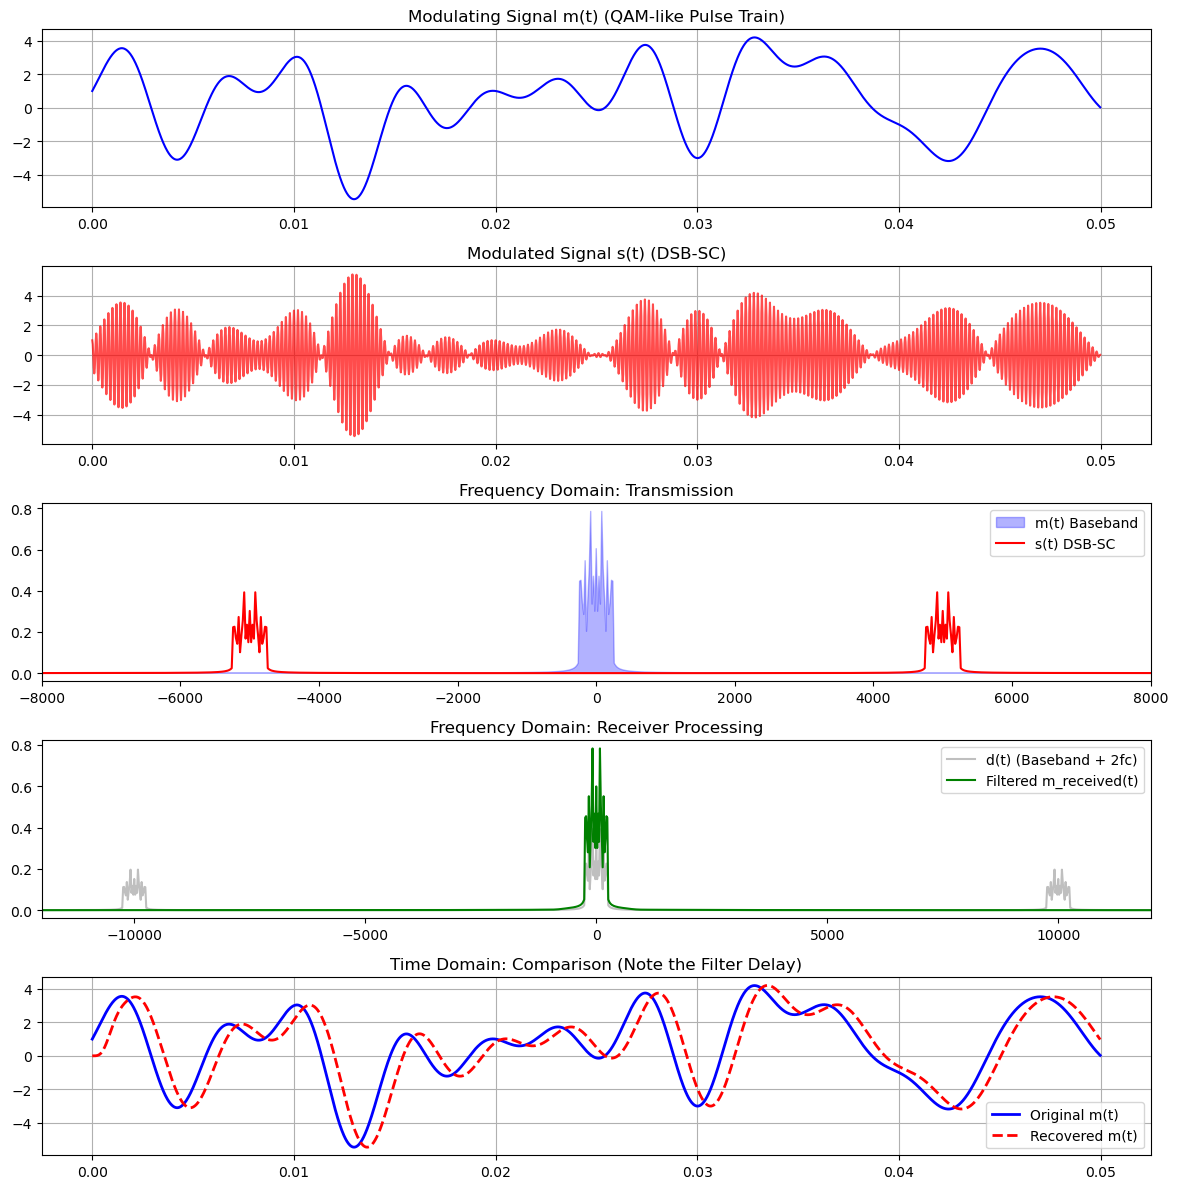

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import butter, lfilter

# Parameters
fs = 40000                     # Higher sampling for better resolution
T_sym = 0.002                  # Symbol period (determines bandwidth)
num_symbols = 25               # Number of random pulses
t = np.arange(0, num_symbols * T_sym, 1/fs)

# 1. Create a "QAM-like" baseband signal m(t)
# We generate random levels and convolve them with a Sinc pulse
np.random.seed(42) 
symbols = np.random.choice([-3, -1, 1, 3], num_symbols) # 4-level (like 16-QAM I-channel)
m_t = np.zeros_like(t)

for i, sym in enumerate(symbols):
    t_center = i * T_sym
    # Sinc pulse provides the "brick wall" bandwidth limit
    m_t += sym * np.sinc((t - t_center) / T_sym)

fc = 5000                      # Carrier frequency (5kHz)
p_t = np.cos(2 * np.pi * fc * t)

# 2. Modulation (DSB-SC)
s_t = m_t * p_t

# 3. Demodulation
d_t = s_t * p_t 

# 4. Low-Pass Filter (Eliminate 2fc)
def lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return lfilter(b, a, data)

# Cutoff set to include the main lobe of the Sinc (~1/T_sym = 500Hz)
m_received = lowpass_filter(d_t, 800, fs) * 2

# Frequency Domain Calculation
def get_spectrum(signal, fs):
    n = len(signal)
    freqs = fftshift(fftfreq(n, 1/fs))
    spectrum = fftshift(np.abs(fft(signal)) / n)
    return freqs, spectrum

f_axis, M_f = get_spectrum(m_t, fs)
_, S_f = get_spectrum(s_t, fs)
_, D_f = get_spectrum(d_t, fs)
_, Mreceived_f = get_spectrum(m_received, fs)

# Plotting
plt.figure(figsize=(12, 12))

# Subplot 1: Message Time Domain
plt.subplot(5, 1, 1)
plt.plot(t, m_t, 'b')
plt.title('Modulating Signal m(t) (QAM-like Pulse Train)')
plt.grid(True)

# Subplot 2: DSB-SC Time Domain
plt.subplot(5, 1, 2)
plt.plot(t, s_t, 'r', alpha=0.7)
plt.title('Modulated Signal s(t) (DSB-SC)')
plt.grid(True)

# Subplot 3: Spectra of m(t) and s(t)
plt.subplot(5, 1, 3)
plt.fill_between(f_axis, M_f, color='blue', alpha=0.3, label='m(t) Baseband')
plt.plot(f_axis, S_f, 'r', label='s(t) DSB-SC')
plt.title('Frequency Domain: Transmission')
plt.xlim(-8000, 8000)
plt.legend()

# Subplot 4: Spectrum at Receiver (Before and After LPF)
plt.subplot(5, 1, 4)
plt.plot(f_axis, D_f, 'gray', alpha=0.5, label='d(t) (Baseband + 2fc)')
plt.plot(f_axis, Mreceived_f, 'g', label='Filtered m_received(t)')
plt.title('Frequency Domain: Receiver Processing')
plt.xlim(-12000, 12000)
plt.legend()

# Subplot 5: Comparison
plt.subplot(5, 1, 5)
plt.plot(t, m_t, 'b', lw=2, label='Original m(t)')
plt.plot(t, m_received, 'r--', lw=2, label='Recovered m(t)')
plt.title('Time Domain: Comparison (Note the Filter Delay)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()